In [1]:
import pandas as pd
import numpy as np

In [21]:
df = pd.read_csv('alpha_test.csv', sep="\t", header=None)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10848 entries, 0 to 10847
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       10848 non-null  float64
 1   1       10848 non-null  float64
 2   2       10848 non-null  float64
 3   3       10848 non-null  float64
 4   4       10848 non-null  float64
 5   5       10848 non-null  float64
 6   6       10848 non-null  float64
 7   7       10848 non-null  float64
 8   8       10848 non-null  float64
 9   9       10848 non-null  float64
 10  10      10848 non-null  float64
 11  11      10848 non-null  float64
 12  12      10848 non-null  float64
 13  13      10848 non-null  float64
 14  14      10848 non-null  float64
 15  15      10848 non-null  float64
 16  16      10848 non-null  float64
 17  17      10848 non-null  float64
 18  18      10848 non-null  float64
 19  19      10848 non-null  float64
 20  20      10848 non-null  float64
 21  21      10848 non-null  float64
 22

In [23]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,145.0,-379011.914612,46784.257505,-91942.738526,-22847.416740,-660970.140811,-34420.166543,-34062.985666,-45813.923575,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.789137e+09,0.0
1,146.0,-380199.239278,46885.287390,-92928.361050,-22783.311937,-661958.266730,-34193.877482,-34020.427945,-45828.407506,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.789137e+09,0.0
2,147.0,-379256.263883,47307.914175,-92207.561995,-22779.646251,-661236.484198,-33955.071444,-34066.383131,-45933.728925,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.789137e+09,0.0
3,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.789137e+09,0.0
4,1.0,-342352.907938,47312.205709,-88616.977765,-22038.551812,-651219.505217,-33017.192247,-34528.170172,-45747.851819,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.789137e+09,0.0


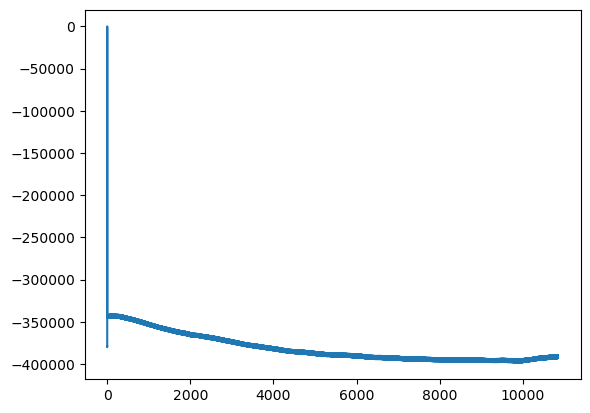

In [24]:
import matplotlib.pyplot as plt
#plt.plot(df[1][100:1000])
plt.plot(df[1])
#plt.axis(xmin=1000, xmax=3000, ymin=-370000, ymax=-350000) # change the axis limits on the graph to zoom

In [26]:
ts = df[1] # get data from column 1
ts = ts[100:] # removing initial 100 time points

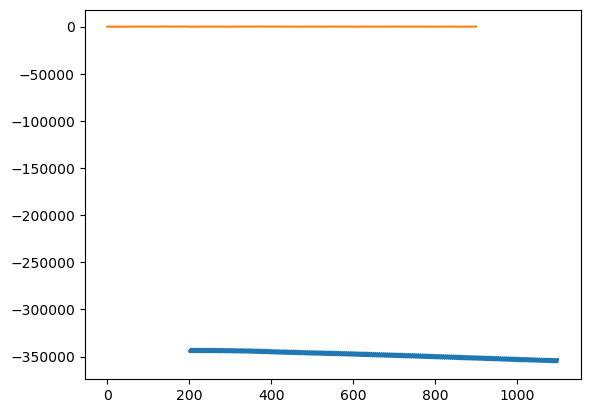

In [34]:
from scipy import signal
import matplotlib.pyplot as plt
import numpy as np
sampling_rate = 250
Nyquist = sampling_rate / 2.0
b, a = signal.butter(4, [1.0 / Nyquist, 35.0 / Nyquist], 'bandpass') # create a filter
filtered = signal.filtfilt(b, a, ts) # apply the filter to signal ts

plt.plot(ts[100:1000])
plt.plot(filtered[100:1000])

Text(0.5, 0, 'time (s)')

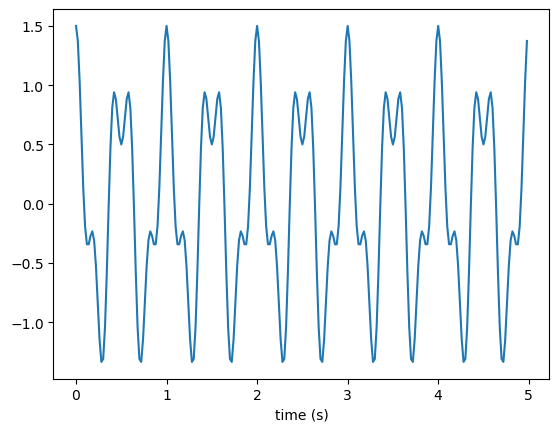

In [35]:
dt = 0.02 # time step (sampling interval in second)
sampling_rate = 50 # sampling rate
f1 = 2 # frequency in Hertz
f2 = 5 # frequency in Hertz
t = np.arange(0,5,dt) # time points with time in second
#print(t)
s = np.cos(2*np.pi*f1*t) + 0.5 * np.cos(2*np.pi*f2*t) # signal (oscillation)
plt.plot(t, s)
plt.xlabel("time (s)")

In [36]:
print(freq)

[0.00000000e+00 2.32601414e-02 4.65202828e-02 ... 1.24953480e+02
 1.24976740e+02 1.25000000e+02]


Text(0.5, 0, 'freq')

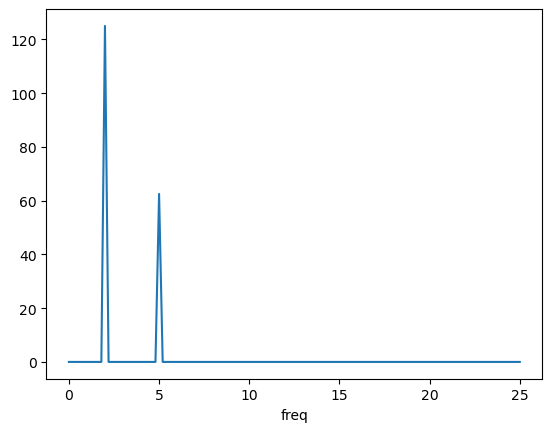

In [37]:
# Fourier analysis
freq = np.fft.rfftfreq(s.size, d=dt) # get frequency range
pw = np.abs(np.fft.rfft(s)) # power spectrum

plt.plot(freq, pw)
plt.xlabel("freq")

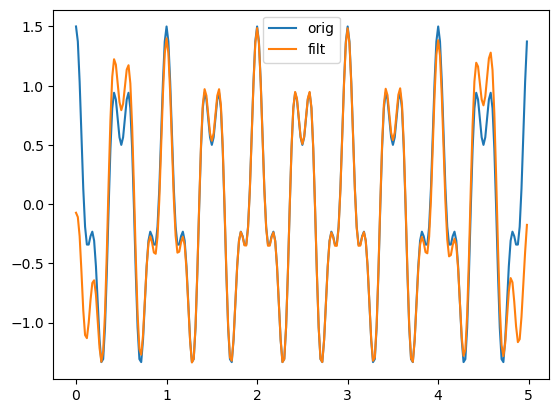

In [39]:
Nyquist = sampling_rate / 2.0 # Nyquist frequency
b, a = signal.butter(4, [1.0 / Nyquist, 10.0 / Nyquist], 'bandpass') # bandpass filter for band between 1 and 35 Hz
#b, a = signal.butter(4, 5.0 / Nyquist, 'lowpass') # bandpass filter for band between 1 and 35 Hz
filt_s = signal.filtfilt(b, a, s)
plt.plot(t, s, label ='orig')
plt.plot(t, filt_s, label ='filt')
plt.legend()
#plt.axis(xmax=1.0)